# Macro Data — Fetch, Transform, and Lag Generation
Fetches macroeconomic series from FRED, computes standard transformations,
and generates lag variables for the five canonical PD model series.

Series are grouped by economic channel matching the mortgage PD model literature.

No variable selection or stationarity testing here — those happen downstream
in the PD model notebook.

**Output:** `macro_panel_quarterly.csv`
- All raw series and their standard transforms
- Lag transforms (lag 1, lag 2) for canonical PD model series:
  `unemployment_rate`, `hpi_cs`, `real_gdp`, `treasury_10y`, `hy_spread`

In [1]:
!pip install pandas_datareader

## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import pandas_datareader.data as pdr
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 2. Series Configuration
Each series is fetched from its own earliest available start date to maximise history.
Series are organised by economic channel — this grouping directly maps to the
theoretical channels through which the macro environment affects mortgage default:

| Channel | Mechanism | Key series |
|---|---|---|
| **Labour market** | Income shocks drive inability to pay | Unemployment, payrolls, wages |
| **Housing market** | Equity shocks drive unwillingness to pay | HPI, starts, supply |
| **Interest rates** | Payment shocks (ARM) and refinancing channel | Mortgage rate, Treasury, spreads |
| **Economic activity** | Broad conditions affect income and confidence | GDP, industrial production |
| **Inflation and prices** | Real debt burden, nominal income growth | CPI, PCE, OER, wages |
| **Credit conditions** | Lender willingness, market stress | HY spread, BBB spread, delinquency |
| **Demographics** | Long-run housing demand | Working-age population, population |

In [3]:
END = '2025-09-30'

# (fred_id, column_name, resample_method, start_date, group)
# 'last' : last observation in quarter (levels)
# 'mean' : average across quarter (rates, flows)
SERIES = [

    # ── Labour market ─────────────────────────────────────────────────
    ('UNRATE',         'unemployment_rate',        'last', '1948-01-01', 'labour'),
    ('PAYEMS',         'nonfarm_payrolls',          'last', '1939-01-01', 'labour'),
    ('CIVPART',        'labor_force_part_rate',     'last', '1948-01-01', 'labour'),
    ('CES0500000003',  'avg_hourly_earnings',       'last', '2006-01-01', 'labour'),

    # ── Housing market ────────────────────────────────────────────────
    ('USSTHPI',        'hpi_fhfa',                 'last', '1991-01-01', 'housing'),
    ('CSUSHPINSA',     'hpi_cs',                   'last', '1987-01-01', 'housing'),
    ('HOUST',          'housing_starts',            'last', '1959-01-01', 'housing'),
    ('PERMIT',         'building_permits',          'last', '1960-01-01', 'housing'),
    ('MSACSR',         'months_supply_homes',       'last', '1963-01-01', 'housing'),

    # ── Interest rates ────────────────────────────────────────────────
    ('MORTGAGE30US',   'mortgage_rate_30y',         'mean', '1971-01-01', 'rates'),
    ('DGS10',          'treasury_10y',              'mean', '1953-01-01', 'rates'),
    ('DGS2',           'treasury_2y',               'mean', '1976-01-01', 'rates'),
    ('FEDFUNDS',       'fed_funds_rate',             'last', '1954-01-01', 'rates'),
    ('DPRIME',         'prime_rate',                'last', '1955-01-01', 'rates'),

    # ── Economic activity ─────────────────────────────────────────────
    ('GDPC1',          'real_gdp',                 'last', '1947-01-01', 'activity'),
    ('INDPRO',         'industrial_production',     'last', '1919-01-01', 'activity'),
    ('RSAFS',          'retail_sales',              'last', '1992-01-01', 'activity'),
    ('UMCSENT',        'consumer_sentiment',        'last', '1952-01-01', 'activity'),

    # ── Inflation and prices ──────────────────────────────────────────
    ('CPIAUCSL',       'cpi_headline',              'last', '1947-01-01', 'inflation'),
    ('CPILFESL',       'cpi_core',                  'last', '1957-01-01', 'inflation'),
    ('PCEPI',          'pce_deflator',              'last', '1959-01-01', 'inflation'),
    ('CUSR0000SEHC',   'cpi_oer',                   'last', '1983-01-01', 'inflation'),
    ('CUSR0000SEHA',   'cpi_rent',                  'last', '1983-01-01', 'inflation'),
    ('DSPIC96',        'real_disp_income',          'last', '1959-01-01', 'inflation'),

    # ── Credit conditions ─────────────────────────────────────────────
    ('BAMLH0A0HYM2',   'hy_spread',                'mean', '1997-01-01', 'credit'),
    ('BAMLC0A4CBBB',   'bbb_spread',               'mean', '1997-01-01', 'credit'),
    ('DRCCLACBS',      'consumer_delinquency_rate', 'last', '1985-01-01', 'credit'),
    ('BOGZ1FL192090005Q', 'household_networth',     'last', '1952-01-01', 'credit'),
    ('CMDEBT',         'household_debt',            'last', '1945-01-01', 'credit'),

    # ── Demographics ──────────────────────────────────────────────────
    ('LFWA64TTUSM647S', 'working_age_pop',          'last', '1960-01-01', 'demographics'),
    ('POPTHM',          'total_population',          'last', '1959-01-01', 'demographics'),
]

# Build lookup: name -> group
SERIES_GROUP = {name: grp for _, name, _, _, grp in SERIES}
print(f'Total series defined: {len(SERIES)}')
from collections import Counter
group_counts = Counter(grp for _, _, _, _, grp in SERIES)
for grp, cnt in sorted(group_counts.items()):
    print(f'  {grp:<15}: {cnt} series')

Total series defined: 31
  activity       : 4 series
  credit         : 5 series
  demographics   : 2 series
  housing        : 5 series
  inflation      : 6 series
  labour         : 4 series
  rates          : 5 series


## 3. Transform Configuration
Transformations are defined per raw series. The transform types are:

- `diff_1` : quarter-on-quarter change (for rates, spreads, levels)
- `diff_4` : year-on-year change (for levels that are already in growth-rate form)
- `log_diff_4` : year-on-year log difference — best for price indices and quantities (stationary, scale-invariant)
- `log_diff_1` : quarter-on-quarter log difference
- `pct_4` : simple year-on-year % change (kept for PD model backward-compatibility)
- `('spread', other)` : col minus another col (derived spreads)

In [4]:
TRANSFORMS = {

    # Labour market
    'unemployment_rate':       ['diff_1', 'diff_4', 'log_diff_4', 'log_diff_1'],
    'nonfarm_payrolls':        ['log_diff_4', 'log_diff_1'],
    'labor_force_part_rate':   ['diff_1', 'diff_4'],
    'avg_hourly_earnings':     ['log_diff_4'],

    # Housing
    'hpi_fhfa':                ['log_diff_4', 'log_diff_1', 'pct_4'],
    'hpi_cs':                  ['log_diff_4', 'log_diff_1'],
    'housing_starts':          ['log_diff_4'],
    'building_permits':        ['log_diff_4'],
    'months_supply_homes':     ['diff_1', 'diff_4'],

    # Interest rates
    'mortgage_rate_30y':       ['diff_1', 'diff_4', ('spread', 'treasury_10y')],
    'treasury_10y':            ['diff_1', 'diff_4', ('spread', 'treasury_2y')],
    'treasury_2y':             ['diff_1', 'diff_4'],
    'fed_funds_rate':          ['diff_1', 'diff_4'],
    'prime_rate':              ['diff_1'],

    # Economic activity
    'real_gdp':                ['log_diff_4', 'log_diff_1'],
    'industrial_production':   ['log_diff_4'],
    'retail_sales':            ['log_diff_4'],
    'consumer_sentiment':      ['diff_1', 'diff_4'],

    # Inflation
    'cpi_headline':            ['log_diff_4', 'log_diff_1'],
    'cpi_core':                ['log_diff_4'],
    'pce_deflator':            ['log_diff_4'],
    'cpi_oer':                 ['log_diff_4'],
    'cpi_rent':                ['log_diff_4'],
    'real_disp_income':        ['log_diff_4'],

    # Credit conditions
    'hy_spread':               ['diff_1'],
    'bbb_spread':              ['diff_1'],
    'consumer_delinquency_rate': ['diff_1', 'diff_4'],
    'household_networth':      ['log_diff_4'],
    'household_debt':          ['log_diff_4'],

    # Demographics
    'working_age_pop':         ['log_diff_4'],
    'total_population':        ['log_diff_4'],
}

SUFFIX = {
    'diff_1':     '_qoq_change',
    'diff_4':     '_yoy_change',
    'pct_4':      '_growth_yoy',
    'log_diff_4': '_log_diff_4',
    'log_diff_1': '_log_diff_1',
}

## 4. Fetch

In [5]:
def fetch_all():
    frames = []
    for fred_id, name, method, start, group in SERIES:
        try:
            raw = pdr.DataReader(fred_id, 'fred', start, END).squeeze().dropna()
            q   = raw.resample('QS').last() if method == 'last' \
                  else raw.resample('QS').mean()
            frames.append(q.rename(name))
            print(f'  [{group:<12}] {name:<30}  {len(q):3d} qtrs'
                  f'  ({q.first_valid_index().date()} - {q.last_valid_index().date()})')
        except Exception as e:
            print(f'  WARNING: {fred_id} ({name}): {e}')
    df = pd.concat(frames, axis=1)
    df.index.name = 'quarter'
    return df


print('Fetching from FRED...')
raw = fetch_all()
print(f'\nRaw panel: {raw.shape[0]} quarters x {raw.shape[1]} series')

Fetching from FRED...
  [labour      ] unemployment_rate               311 qtrs  (1948-01-01 - 2025-07-01)
  [labour      ] nonfarm_payrolls                347 qtrs  (1939-01-01 - 2025-07-01)
  [labour      ] labor_force_part_rate           311 qtrs  (1948-01-01 - 2025-07-01)
  [labour      ] avg_hourly_earnings              79 qtrs  (2006-01-01 - 2025-07-01)
  [housing     ] hpi_fhfa                        139 qtrs  (1991-01-01 - 2025-07-01)
  [housing     ] hpi_cs                          155 qtrs  (1987-01-01 - 2025-07-01)
  [housing     ] housing_starts                  267 qtrs  (1959-01-01 - 2025-07-01)
  [housing     ] building_permits                263 qtrs  (1960-01-01 - 2025-07-01)
  [housing     ] months_supply_homes             251 qtrs  (1963-01-01 - 2025-07-01)
  [rates       ] mortgage_rate_30y               218 qtrs  (1971-04-01 - 2025-07-01)
  [rates       ] treasury_10y                    255 qtrs  (1962-01-01 - 2025-07-01)
  [rates       ] treasury_2y               

## 5. Transform

In [6]:
def compute_transforms(df):
    out = df.copy()

    # Derived spreads not in TRANSFORMS
    if 'treasury_10y' in df.columns and 'treasury_2y' in df.columns:
        out['yield_curve_spread'] = df['treasury_10y'] - df['treasury_2y']
    if 'mortgage_rate_30y' in df.columns and 'treasury_10y' in df.columns:
        # already handled in TRANSFORMS via ('spread', 'treasury_10y')
        pass

    for col, tlist in TRANSFORMS.items():
        if col not in df.columns:
            continue
        for t in tlist:
            if t == 'diff_1':
                out[col + SUFFIX['diff_1']] = df[col].diff(1)
            elif t == 'diff_4':
                out[col + SUFFIX['diff_4']] = df[col].diff(4)
            elif t == 'pct_4':
                out[col + SUFFIX['pct_4']] = df[col].pct_change(4) * 100
            elif t == 'log_diff_4':
                out[col + SUFFIX['log_diff_4']] = (
                    np.log(df[col]) - np.log(df[col].shift(4))
                ) * 100
            elif t == 'log_diff_1':
                out[col + SUFFIX['log_diff_1']] = (
                    np.log(df[col]) - np.log(df[col].shift(1))
                ) * 100
            elif isinstance(t, tuple) and t[0] == 'spread':
                other = t[1]
                if other in df.columns:
                    out[f'{col}_minus_{other}'] = df[col] - df[other]

    print(f'Transforms: {df.shape[1]} raw -> {out.shape[1]} total columns')
    return out


macro = compute_transforms(raw)
print(macro.shape)
macro.head(3)

Transforms: 31 raw -> 82 total columns
(427, 82)


,unemployment_rate,nonfarm_payrolls,labor_force_part_rate,avg_hourly_earnings,hpi_fhfa,hpi_cs,housing_starts,building_permits,months_supply_homes,mortgage_rate_30y,...,cpi_rent_log_diff_4,real_disp_income_log_diff_4,hy_spread_qoq_change,bbb_spread_qoq_change,consumer_delinquency_rate_qoq_change,consumer_delinquency_rate_yoy_change,household_networth_log_diff_4,household_debt_log_diff_4,working_age_pop_log_diff_4,total_population_log_diff_4
quarter,,,,,,,,,,,,,,,,,,,,,
1919-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1919-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1919-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Lag Generation for PD Model Canonical Series
The PD model variable selection generates lag transforms on the fly during
screening but the final selected variables need to exist in this panel
so they can be merged into the loan panel during training.

Lags are generated for the five canonical series and their primary transforms.
Lag notation: `_lag1` = 1 quarter lag, `_lag2` = 2 quarter lag.

In [7]:
# Canonical series used in PD model variable selection
# These are the only series for which lags are generated
# Other series do not need lags -- they are not candidates in the PD model

PD_CANONICAL = [
    'unemployment_rate',
    'hpi_cs',
    'real_gdp',
    'treasury_10y',
    'hy_spread',
]

LAGS = [1, 2]

# Identify all transformed columns belonging to canonical series
# These are columns whose name starts with a canonical series name
# and is not a raw level (i.e. has a transform suffix)
STATIONARY_SUFFIXES = (
    '_qoq_change', '_yoy_change',
    '_log_growth_yoy', '_log_growth_qoq',
    '_growth_yoy', '_minus_',
    '_diff_1', '_diff_4',
    '_log_diff_4', '_log_diff_1',
)

lag_frames = {}
for raw in PD_CANONICAL:
    # Find all transformed columns for this canonical series
    transform_cols = [
        c for c in macro.columns
        if c.startswith(raw)
        and c != raw  # exclude raw level
        and any(sfx in c for sfx in STATIONARY_SUFFIXES)
    ]
    for col in transform_cols:
        for lag in LAGS:
            lag_name = f'{col}_lag{lag}'
            lag_frames[lag_name] = macro[col].shift(lag)

lag_df = pd.DataFrame(lag_frames, index=macro.index)
macro  = pd.concat([macro, lag_df], axis=1)

print(f'Added {len(lag_frames)} lag columns')
print(f'Total columns: {macro.shape[1]}')
print()
print('Lag columns per canonical series:')
for raw in PD_CANONICAL:
    lag_cols = [c for c in macro.columns
                if c.startswith(raw) and '_lag' in c]
    print(f'  {raw:<20}: {len(lag_cols)} lag columns')

Added 24 lag columns
Total columns: 106

Lag columns per canonical series:
  unemployment_rate   : 8 lag columns
  hpi_cs              : 4 lag columns
  real_gdp            : 4 lag columns
  treasury_10y        : 6 lag columns
  hy_spread           : 2 lag columns


## 6. Coverage by Group

In [8]:
# Print coverage summary grouped by economic channel
# This shows which channels have long history vs short history

print(f'Date range: {macro.index.min().date()} to {macro.index.max().date()}')
print(f'Columns:    {macro.shape[1]}')
print()

# Only show raw series (not transforms) grouped by channel
raw_names = [name for _, name, _, _, _ in SERIES]
groups_order = ['labour', 'housing', 'rates', 'activity', 'inflation', 'credit', 'demographics']

for grp in groups_order:
    members = [n for n in raw_names if SERIES_GROUP.get(n) == grp]
    print(f'── {grp.upper()} ────────────────────────────────────────────────')
    for col in members:
        if col not in macro.columns:
            print(f'  {col:<35}  MISSING')
            continue
        s = macro[col].dropna()
        print(f'  {col:<35}  {len(s):4d} qtrs  '
              f'{str(s.index.min().date()):>12} - {str(s.index.max().date()):>12}')
    print()

Date range: 1919-01-01 to 2025-07-01
Columns:    106

── LABOUR ────────────────────────────────────────────────
  unemployment_rate                     311 qtrs    1948-01-01 -   2025-07-01
  nonfarm_payrolls                      347 qtrs    1939-01-01 -   2025-07-01
  labor_force_part_rate                 311 qtrs    1948-01-01 -   2025-07-01
  avg_hourly_earnings                    79 qtrs    2006-01-01 -   2025-07-01

── HOUSING ────────────────────────────────────────────────
  hpi_fhfa                              139 qtrs    1991-01-01 -   2025-07-01
  hpi_cs                                155 qtrs    1987-01-01 -   2025-07-01
  housing_starts                        267 qtrs    1959-01-01 -   2025-07-01
  building_permits                      263 qtrs    1960-01-01 -   2025-07-01
  months_supply_homes                   251 qtrs    1963-01-01 -   2025-07-01

── RATES ────────────────────────────────────────────────
  mortgage_rate_30y                     218 qtrs    1971-04-01 - 

## 7. Historical Plots by Group

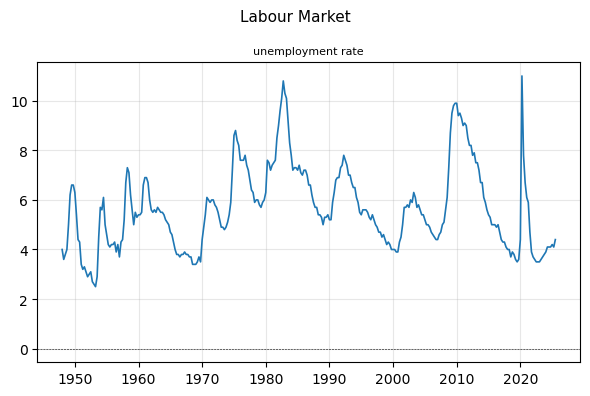

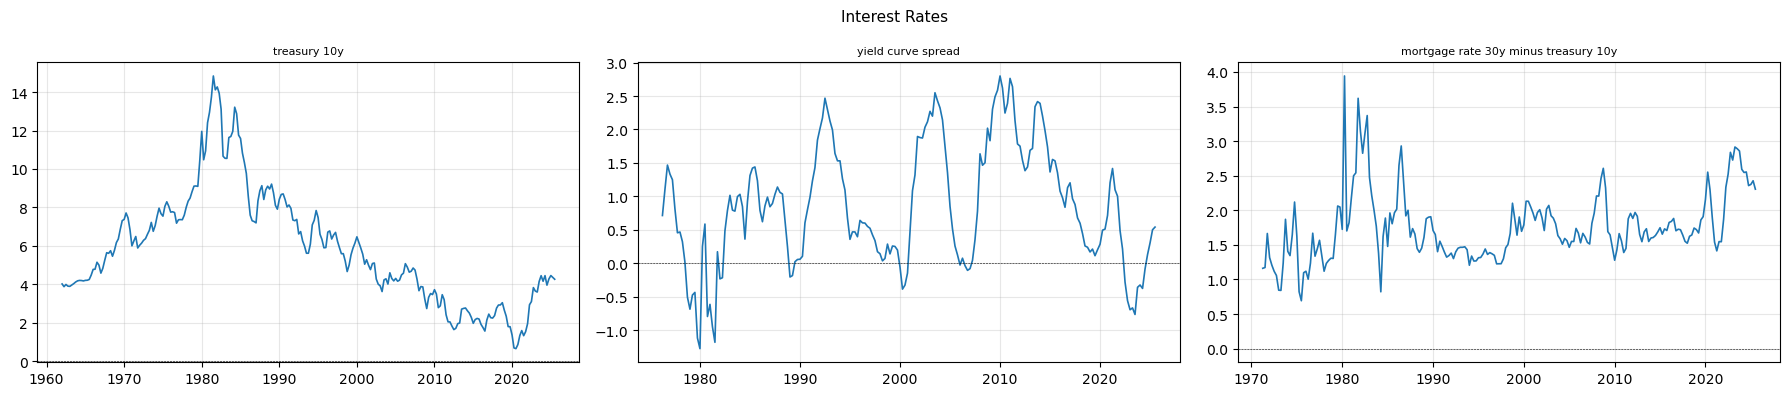

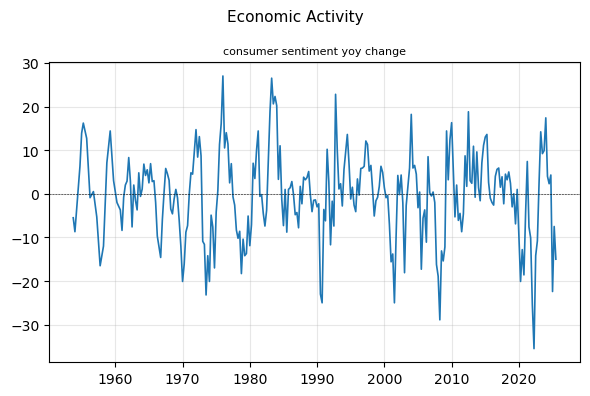

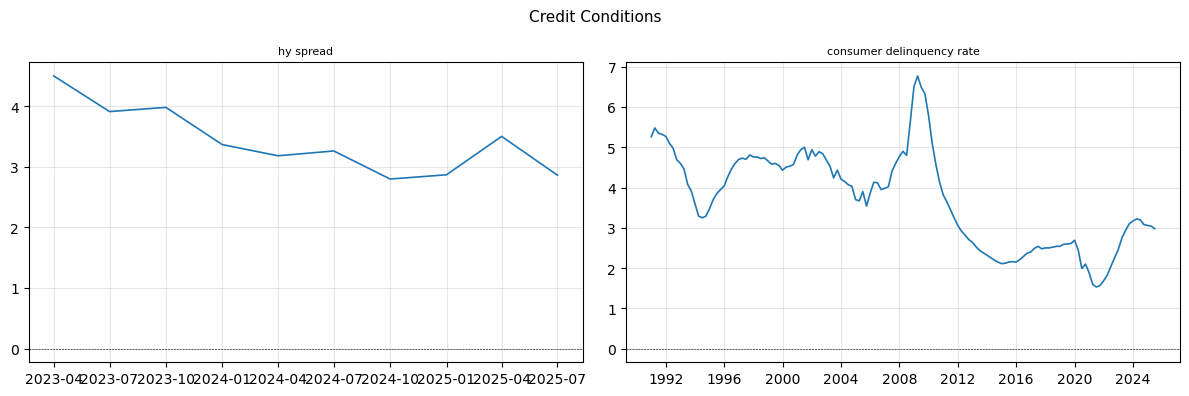

In [9]:
# Plot key transformed series by group for visual inspection
# One panel per group showing the primary stationary transform

PLOT_VARS = {
    'Labour Market':      ['unemployment_rate', 'nonfarm_payrolls_log_growth_yoy'],
    'Housing Market':     ['hpi_fhfa_log_growth_yoy', 'housing_starts_log_growth_yoy'],
    'Interest Rates':     ['treasury_10y', 'yield_curve_spread', 'mortgage_rate_30y_minus_treasury_10y'],
    'Economic Activity':  ['real_gdp_log_growth_yoy', 'consumer_sentiment_yoy_change'],
    'Inflation':          ['cpi_headline_log_growth_yoy', 'cpi_core_log_growth_yoy'],
    'Credit Conditions':  ['hy_spread', 'consumer_delinquency_rate'],
}

for group_name, vars_list in PLOT_VARS.items():
    vars_available = [v for v in vars_list if v in macro.columns]
    if not vars_available:
        continue
    fig, axes = plt.subplots(1, len(vars_available), figsize=(6 * len(vars_available), 4))
    if len(vars_available) == 1:
        axes = [axes]
    for ax, var in zip(axes, vars_available):
        s = macro[var].dropna()
        ax.plot(s.index, s.values, linewidth=1.2)
        ax.set_title(var.replace('_', ' '), fontsize=8)
        ax.axhline(0, color='k', linewidth=0.4, linestyle='--')
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('')
    fig.suptitle(f'{group_name}', fontsize=11)
    fig.tight_layout()
    plt.show()

## 8. Save

In [10]:
macro.to_csv('macro_panel_quarterly.csv')
print('Saved: macro_panel_quarterly.csv')
print(f'  {macro.shape[0]} quarters x {macro.shape[1]} columns')
print(f'  {macro.index.min().date()} to {macro.index.max().date()}')
print()
print('Load with:')
print("  macro = pd.read_csv('macro_panel_quarterly.csv', index_col=0, parse_dates=True)")

Saved: macro_panel_quarterly.csv
  427 quarters x 106 columns
  1919-01-01 to 2025-07-01

Load with:
  macro = pd.read_csv('macro_panel_quarterly.csv', index_col=0, parse_dates=True)
